In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import RepeatVector, TimeDistributed

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Activation, Input


In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
nox = df.copy()

nox.head()


Saving cleanednox_newusd.csv to cleanednox_newusd (3).csv


,Date,Time,NOx(GT),PT08.S3(NOx),Temperature (C),Relative Humidity,Absolute Humidity,Datetime
0,2004-03-10,18:00:00,0.111036,0.310885,0.333333,0.499371,0.280066,2004-03-10 18:00:00
1,2004-03-10,19:00:00,0.068382,0.360864,0.326882,0.484277,0.264282,2004-03-10 19:00:00
2,2004-03-10,20:00:00,0.087339,0.346463,0.296774,0.563522,0.276352,2004-03-10 20:00:00
3,2004-03-10,21:00:00,0.115098,0.326133,0.277419,0.638994,0.294190,2004-03-10 21:00:00
4,2004-03-10,22:00:00,0.087339,0.373994,0.281720,0.633962,0.295216,2004-03-10 22:00:00


In [35]:
def plot_lr_data(mu, prediction_horizon, number_of_samples, tp_pred, yp_pred, time_series, sensor_values, first=True):
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle("Linear baseline prediction vs sensor", fontsize=18, fontweight="bold")
    if first:
        i0, i1 = 0,200
    else:
        i0, i1 = max(0, number_of_samples - 200), number_of_samples
    ax.plot(tp_pred[i0:i1], yp_pred[i0:i1], label="Predicted")
    ax.plot(time_series.iloc[i0:i1, 0], sensor_values.iloc[i0:i1, 0], label="Sensor")
    ax.set_xlabel("time")
    ax.set_ylabel("normalized value")
    ax.legend()
    plt.show()


In [5]:

nox["Datetime"] = pd.to_datetime(nox["Datetime"])
nox["unix"] = nox["Datetime"].apply(lambda x: x.timestamp())

nox.head()


,Date,Time,NOx(GT),PT08.S3(NOx),Temperature (C),Relative Humidity,Absolute Humidity,Datetime,unix
0,2004-03-10,18:00:00,0.111036,0.310885,0.333333,0.499371,0.280066,2004-03-10 18:00:00,1.078942e+09
1,2004-03-10,19:00:00,0.068382,0.360864,0.326882,0.484277,0.264282,2004-03-10 19:00:00,1.078945e+09
2,2004-03-10,20:00:00,0.087339,0.346463,0.296774,0.563522,0.276352,2004-03-10 20:00:00,1.078949e+09
3,2004-03-10,21:00:00,0.115098,0.326133,0.277419,0.638994,0.294190,2004-03-10 21:00:00,1.078952e+09
4,2004-03-10,22:00:00,0.087339,0.373994,0.281720,0.633962,0.295216,2004-03-10 22:00:00,1.078956e+09


In [6]:
"""Setup data and train linear regression model"""

time_series = pd.DataFrame(nox.unix)
sensor_values = pd.DataFrame(nox.filter(["PT08.S3(NOx)"]))

number_of_samples = len(time_series)
prediction_horizon = 24 * 3600
mu = 0.9

tp_pred = np.zeros(number_of_samples - 1)
yp_pred = np.zeros(number_of_samples - 1)

for i in range(2, number_of_samples + 1):
    ts_tmp = time_series[0:i]
    ys_tmp = sensor_values[0:i]
    ns = len(ys_tmp)

    weights = np.ones(ns) * mu
    for k in range(ns):
        weights[k] = weights[k] ** k
    weights = np.flip(weights, 0)

    lm_tmp = LinearRegression()
    model_tmp = lm_tmp.fit(ts_tmp, ys_tmp, sample_weight=weights)

    m_tmp = model_tmp.coef_
    q_tmp = model_tmp.intercept_

    tp = time_series.iloc[i-1, 0] + prediction_horizon
    yp = m_tmp * tp + q_tmp

    tp_pred[i-2] = tp
    yp_pred[i-2] = yp.item()


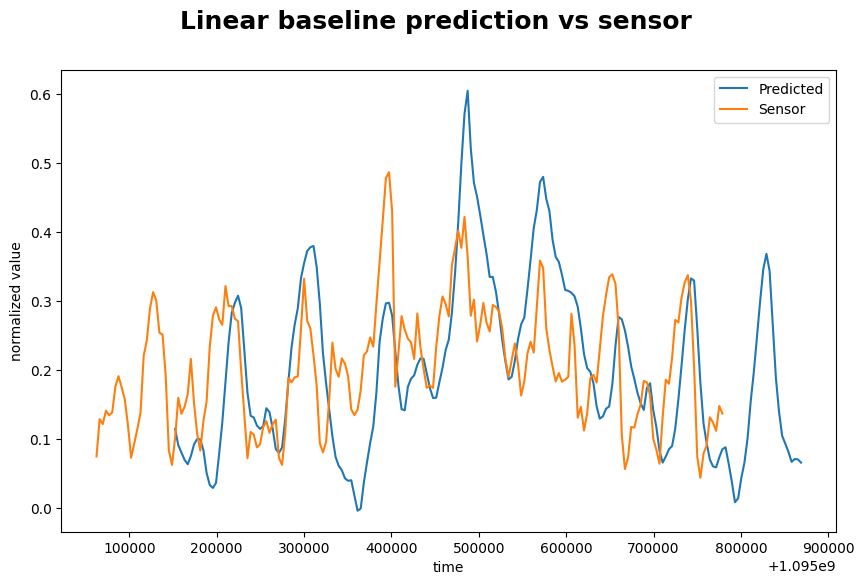

In [7]:
mid = number_of_samples // 2
tp_mid = tp_pred[mid - 200: mid + 200]
yp_mid = yp_pred[mid - 200: mid + 200]
ts_mid = time_series.iloc[mid - 200: mid + 200]
sv_mid = sensor_values.iloc[mid - 200: mid + 200]

plot_lr_data(mu, prediction_horizon, number_of_samples, tp_mid, yp_mid, ts_mid, sv_mid, first=True)


In [ ]:
"""Load current Tableau data so we can add the NOx data to it and save it again"""
tableau = pd.read_csv("../../Data/Benzene/Tableau.csv")
tableau.rename(columns={"preds": "O3_predictions", "drift": "O3_drift"}, inplace=True)

# pull out prediction data
nox_predictions = np.concatenate([np.full(len(df_hourly), np.nan), forecast_df["PT08.S1(CO)"]])

# pull out drift data
co_threshold = df_scaled["CO_residual_smooth"].std() * 2
df_scaled[f"CO_drift"] = df_scaled["CO_residual_smooth"].abs() > co_threshold

nmhc_threshold = df_scaled["NMHC_residual_smooth"].std() * 2
df_scaled[f"NMHC_drift"] = df_scaled["NMHC_residual_smooth"].abs() > nmhc_threshold

# push it all into predictions
co_readings = df_hourly["PT08.S1(CO)"]
tableau["PT08.S1(CO)"] = np.nan
tableau.loc[:len(s)-1, "PT08.S1(CO)"] = co_readings.values
tableau["CO_predictions"] = co_predictions
tableau["CO_drift"] = df_scaled["CO_drift"]

nmhc_readings = df_hourly["PT08.S2(NMHC)"]
tableau["PT08.S2(NMHC)"] = np.nan
tableau.loc[:len(s)-1, "PT08.S2(NMHC)"] = nmhc_readings.values
tableau["NMHC_predictions"] = nmhc_predictions
tableau["NMHC_drift"] = df_scaled["NMHC_drift"]

# and save it
tableau.to_csv("../../Data/Tableau1.csv", index=False)

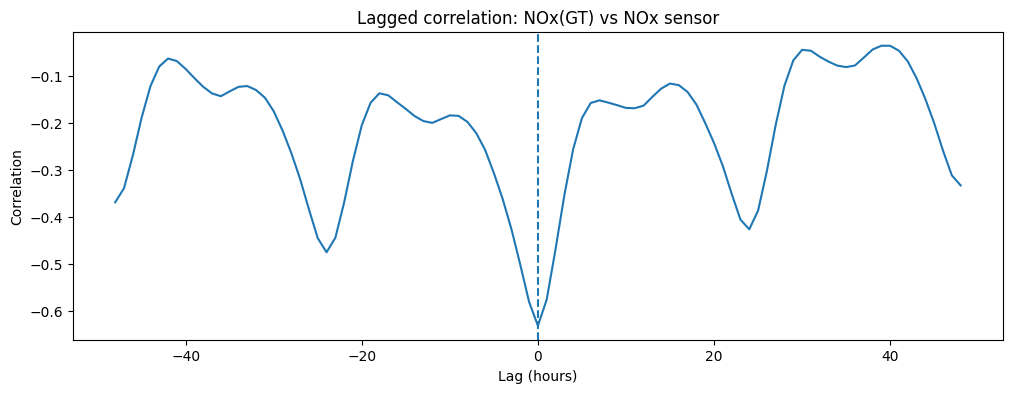

Best lag (hours): 0  Correlation: -0.03543925194368871


In [8]:
GT_COL = "NOx(GT)"
SENSOR_COL = "PT08.S3(NOx)"
if GT_COL in nox.columns and SENSOR_COL in nox.columns:
    max_lag = 48
    lags = range(-max_lag, max_lag + 1)
    a = nox[GT_COL].astype(float)
    b = nox[SENSOR_COL].astype(float)

    cors = []
    for L in lags:
        cors.append(a.corr(b.shift(L)))

    best_lag = int(np.nanargmax(np.abs(cors)) - max_lag)

    plt.figure(figsize=(12,4))
    plt.plot(list(lags), cors)
    plt.axvline(0, linestyle="--")
    plt.title("Lagged correlation: NOx(GT) vs NOx sensor")
    plt.xlabel("Lag (hours)")
    plt.ylabel("Correlation")
    plt.show()

    print("Best lag (hours):", best_lag, " Correlation:", float(np.nanmax(cors)))
else:
    print("GT column not found. We are lagged correlatio")


In [34]:
def plot_loss(history):
    plt.figure(figsize=(8,4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss Over Time")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
def plot_actual_vs_pred(y_true, y_pred, title="Actual vs Predicted", last_n=200):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    plt.figure(figsize=(12,4))
    plt.plot(y_true[-last_n:], label="Actual", linewidth=2)
    plt.plot(y_pred[-last_n:], label="Predicted", linestyle="--")
    plt.title(title + f" (Last {last_n})")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

def plot_rolling_rmse(y_true, y_pred, window=24, title="Rolling RMSE"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_pred - y_true
    rolling = pd.Series(err).rolling(window).apply(lambda x: np.sqrt(np.mean(x**2)), raw=True)
    plt.figure(figsize=(12,4))
    plt.plot(rolling)
    plt.title(title + f"(Window = {window})")
    plt.xlabel("Validation index")
    plt.ylabel("RMSE")
    plt.show()
def plot_error_vs_actual(y_true, y_pred, title="error vs Actual"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_pred - y_true
    plt.figure(figsize=(6,5))
    plt.scatter(y_true, err, s=8)
    plt.axhline(0, linestyle="--")
    plt.title(title)
    plt.xlabel("actual")
    plt.ylabel("Pred -actual")
    plt.show()
def plot_parity(y_true, y_pred, title="Parity  Plot"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    plt.figure(figsize=(6,5))
    plt.scatter(y_true, y_pred, s=8)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()


In [12]:
seq_length = 7 * 24
ph = 24
seq_arrays = np.array(
    [training_data.iloc[i:i + seq_length].values
     for i in range(len(training_data) - seq_length - ph)],
    dtype=np.float32
)

seq_labs = np.array(
    [training_data.iloc[i + seq_length + ph - 1].values[0]
     for i in range(len(training_data) - seq_length - ph)],
    dtype=np.float32
)

seq_arrays.shape, seq_labs.shape


((7293, 168, 1), (7293,))

In [13]:
sensor_data = nox.filter(["PT08.S3(NOx)"])
train, validate = train_test_split(sensor_data, train_size=0.8, random_state=73, shuffle=False)
training_data = train.reset_index(drop=True)
validation_data = validate.reset_index(drop=True)

training_data.shape, validation_data.shape


((7485, 1), (1872, 1))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 5)         │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3)              │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
14/14 - 9s - 643ms/step - loss: 0.0354 - mse: 0.0354 - val_loss: 0.0091 - val_mse: 0.0091
Epoch 2/100
14/14 - 2s - 153ms/step - loss: 0.0173 - mse: 0.0173 - val_loss: 0.0084 - val_mse: 0.0084
Epoch 3/100
14/14 - 2s - 177ms/step - loss: 0.0141 - mse: 0.0141 - val_loss: 0.0106 - val_mse: 0.0106
Epoch 4/100
14/14 - 6s - 457ms/step - loss: 0.0127 - mse: 0.0127 - val_loss: 0.0081 - val_mse: 0.0081
Epoch 5/100
14/14 - 2s - 165ms/step - loss: 0.0121 - mse: 0.0121 - val_loss: 0.0085 - val_mse: 0.0085
Epoch 6/100
14/14 - 2s - 160ms/step - loss: 0.0116 - mse: 0.0116 - val_loss: 0.0081 - val_mse: 0.0081
Epoch 7/100
14/14 - 2s - 155ms/step - loss: 0.0113 - mse: 0.0113 - val_loss: 0.0075 - val_mse: 0.0075
Epoch 8/100
14/14 - 4s - 250ms/step - loss: 0.0112 - mse: 0.0112 - val_loss: 0.0075 - val_mse: 0.0075
Epoch 9/100
14/14 - 2s - 166ms/step - loss: 0.0111 - mse: 0.0111 - val_loss: 0.0067 - val_mse: 0.0067
Epoch 10/100
14/14 - 2s - 167ms/step - loss: 0.0110 - mse: 0.0110 - val_loss:

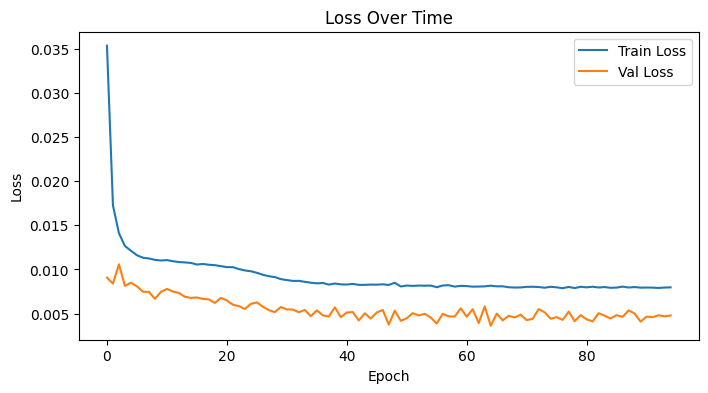

In [14]:

model_path = "LSTM_baseline.keras"

nb_features = 1
nb_out = 1
model = Sequential()
model.add(Input(shape=(seq_length, nb_features)))
model.add(LSTM(units=5, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=3,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=nb_out))
model.add(Activation(keras.activations.linear))
optimizer = keras.optimizers.Adam(learning_rate = 0.01)
model.compile(loss="mean_squared_error", optimizer=optimizer, metrics=["mse"])
print(model.summary())
history = model.fit(seq_arrays,seq_labs,epochs=100,batch_size=500,validation_split=0.05,verbose=2,
callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",min_delta=0,patience=30,verbose=0,mode="min")])

plot_loss(history)


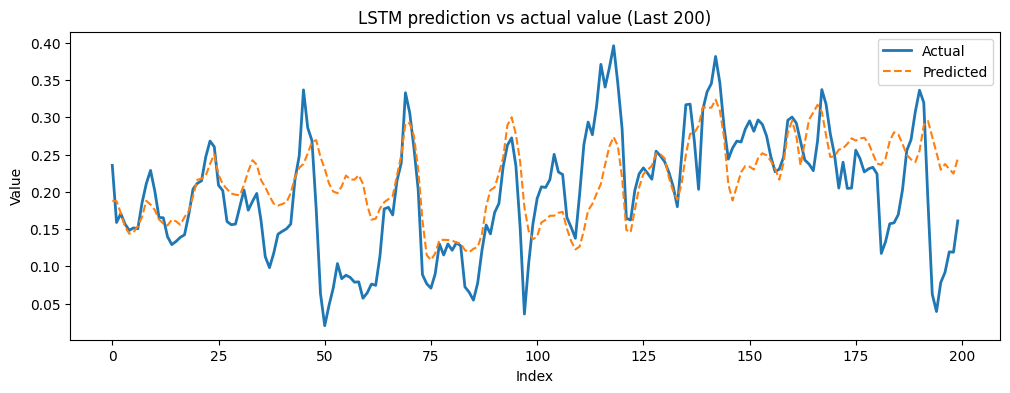

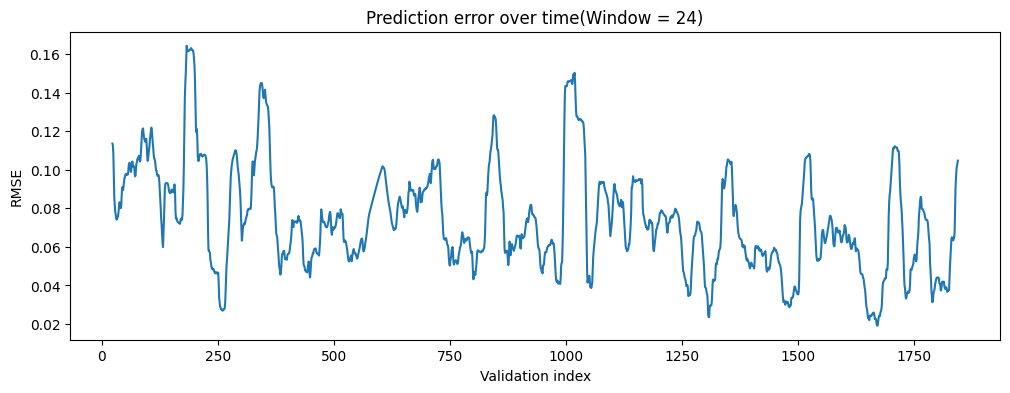

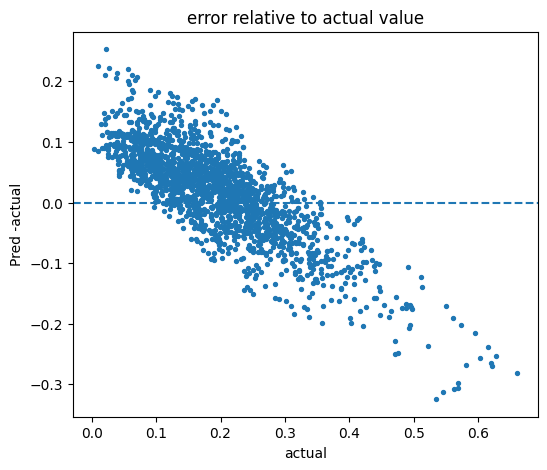

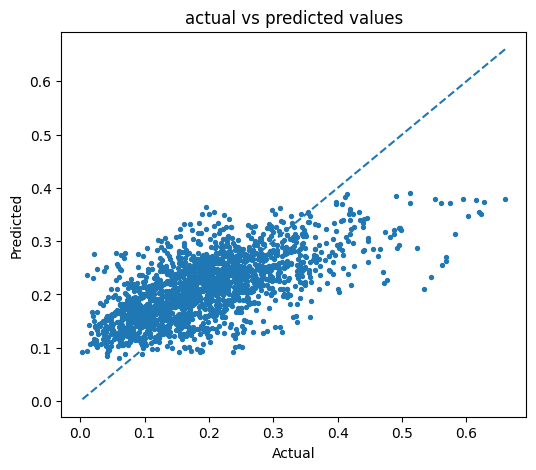

(np.float64(0.09738701062318414), np.float64(0.07938255921267015))

In [15]:
MIN_COUNT = 2
val_arrays = (np.array(tf.keras.utils.pad_sequences([validation_data.iloc[max(0,i):i+seq_length].values for i in range(MIN_COUNT-seq_length, len(validation_data)-seq_length-ph)], maxlen=seq_length, padding="pre", truncating="pre", dtype="float32", value=0.0)).astype(np.float32))
predictions = model.predict(val_arrays, verbose=0).ravel()
val_labs = (np.array([validation_data.iloc[i+seq_length+ph-1].values[0] for i in range(MIN_COUNT-seq_length, len(validation_data)-seq_length-ph)], dtype=np.float32).ravel())

plot_actual_vs_pred(val_labs, predictions, title="LSTM prediction vs actual value", last_n=200)
plot_rolling_rmse(val_labs, predictions, window=24, title="Prediction error over time")
plot_error_vs_actual(val_labs, predictions, title="error relative to actual value")
plot_parity(val_labs, predictions, title="actual vs predicted values")
lstm_rmse = np.sqrt(mean_squared_error(val_labs, predictions))
lstm_rmse
baseline_rmse = np.sqrt(np.mean((yp_pred - sensor_values.iloc[1:, 0].values) **2))
baseline_rmse, lstm_rmse


In [32]:
autoencoder = Sequential()
autoencoder.add(Input(shape=(seq_length, nb_features)))
autoencoder.add(LSTM(16, return_sequences=False))
autoencoder.add(RepeatVector(seq_length))
autoencoder.add(LSTM(16, return_sequences=True))
autoencoder.add(TimeDistributed(Dense(nb_features)))
optimizer_ae = keras.optimizers.Adam(learning_rate=0.001)
autoencoder.compile(loss="mse", optimizer=optimizer_ae)
autoencoder.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 168, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 168, 16)        │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 168, 1)         │            17 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281 (12.82 KB)

 Trainable params: 3,281 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
14/14 - 30s - 2s/step - loss: 0.0225 - val_loss: 0.0100
Epoch 2/100
14/14 - 12s - 847ms/step - loss: 0.0136 - val_loss: 0.0074
Epoch 3/100
14/14 - 20s - 1s/step - loss: 0.0124 - val_loss: 0.0074
Epoch 4/100
14/14 - 20s - 1s/step - loss: 0.0120 - val_loss: 0.0075
Epoch 5/100
14/14 - 12s - 852ms/step - loss: 0.0118 - val_loss: 0.0074
Epoch 6/100
14/14 - 20s - 1s/step - loss: 0.0118 - val_loss: 0.0075
Epoch 7/100
14/14 - 10s - 734ms/step - loss: 0.0117 - val_loss: 0.0076
Epoch 8/100
14/14 - 11s - 779ms/step - loss: 0.0117 - val_loss: 0.0076
Epoch 9/100
14/14 - 10s - 711ms/step - loss: 0.0116 - val_loss: 0.0076
Epoch 10/100
14/14 - 12s - 887ms/step - loss: 0.0116 - val_loss: 0.0076
Epoch 11/100
14/14 - 11s - 802ms/step - loss: 0.0116 - val_loss: 0.0077
Epoch 12/100
14/14 - 12s - 853ms/step - loss: 0.0115 - val_loss: 0.0077


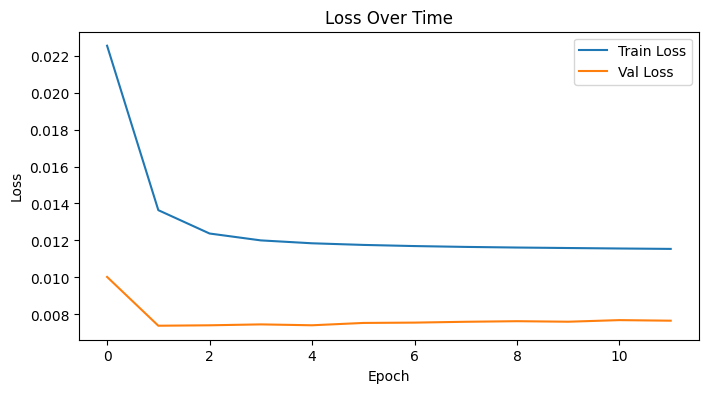

In [18]:
autoencoder.compile(optimizer="adam", loss="mse")
history_ae=autoencoder.fit(seq_arrays,seq_arrays,epochs=100,batch_size=500,validation_split=0.05,verbose=2,callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)])
plot_loss(history_ae)


In [22]:
train_recon = autoencoder.predict(seq_arrays, verbose=0)
train_rec_err =np.mean((train_recon - seq_arrays) ** 2, axis=(1, 2))
val_recon = autoencoder.predict(val_arrays, verbose=0)
val_rec_err = np.mean((val_recon - val_arrays) ** 2, axis=(1, 2))
threshold =np.float32(np.percentile(train_rec_err, 95))
anomaly_idx = np.where(val_rec_err >threshold)[0]
print("Threshold:", threshold)
print("flagged seq:",len(anomaly_idx))


Threshold: 0.070833445
flagged seq: 36


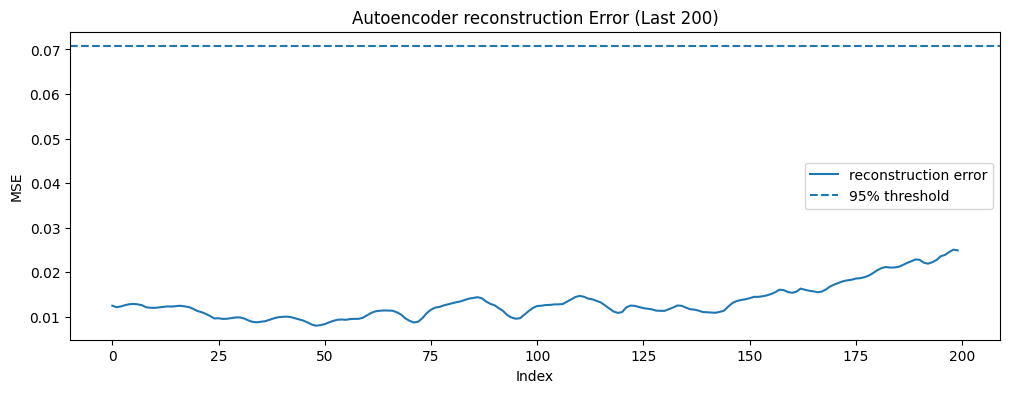

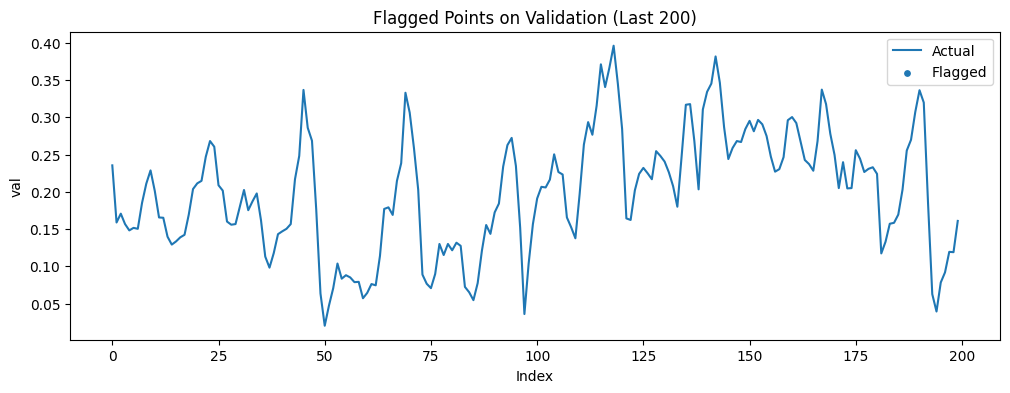

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(val_rec_err[-200:], label="reconstruction error")
plt.axhline(threshold, linestyle="--", label="95% threshold")
plt.legend()
plt.title("Autoencoder reconstruction Error (Last 200)")
plt.xlabel("Index")
plt.ylabel("MSE")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(val_labs[-200:], label="Actual")
idx_last = anomaly_idx[anomaly_idx >= len(val_labs) - 200] - (len(val_labs) - 200)
plt.scatter(idx_last, val_labs[-200:][idx_last], s=15, label="Flagged")
plt.legend()
plt.title("Flagged Points on Validation (Last 200)")
plt.xlabel("Index")
plt.ylabel("val")
plt.show()


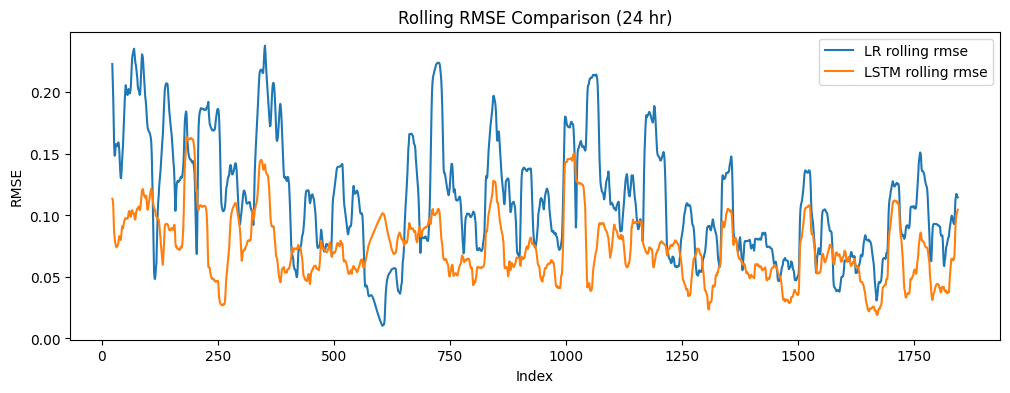

In [29]:
lr_comp = yp_pred[len(training_data):len(training_data) + len(val_labs)]
len(lr_comp), len(val_labs)
window = 24
pred_1d = np.asarray(predictions).ravel()
true_1d = np.asarray(val_labs).ravel()
lr_1d = np.asarray(lr_comp).ravel()
rmse_lr = np.sqrt(pd.Series((lr_1d - true_1d) ** 2).rolling(window).mean())
rmse_lstm = np.sqrt(pd.Series((pred_1d - true_1d) ** 2).rolling(window).mean())
plt.figure(figsize=(12, 4))
plt.plot(rmse_lr, label="LR rolling rmse")
plt.plot(rmse_lstm, label="LSTM rolling rmse")
plt.legend()
plt.title("Rolling RMSE Comparison (24 hr)")
plt.xlabel("Index")
plt.ylabel("RMSE")
plt.show()


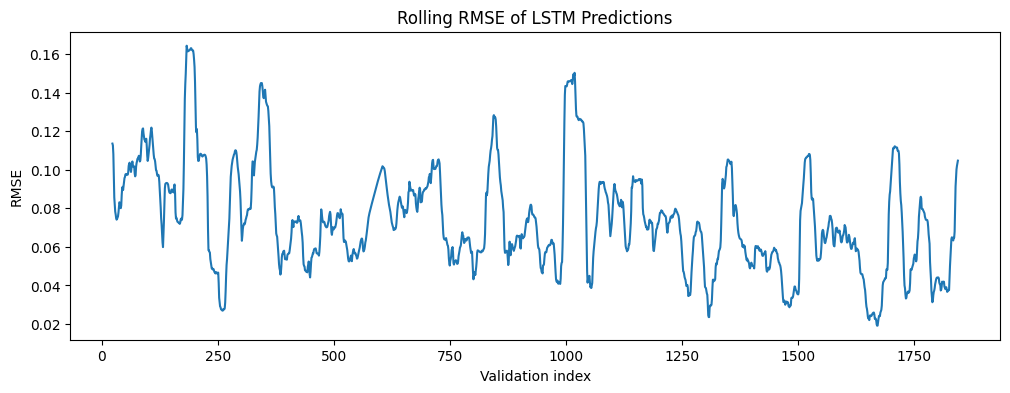

In [31]:
err = (predictions.flatten() - val_labs.flatten())
window = 24
rolling_rmse = pd.Series(err).rolling(window).apply(lambda x: np.sqrt(np.mean(x**2)), raw=True)
plt.figure(figsize=(12,4))
plt.plot(rolling_rmse)
plt.title("Rolling RMSE of LSTM Predictions")
plt.xlabel("Validation index")
plt.ylabel("RMSE")
plt.show()


In [ ]:
"""Load Tableau data, add the NOx data and save it again"""
tableau = pd.read_csv("../../Data/Tableau.csv")

# push NOx readings and predictions
tableau["PT08.S3(NOx)"] = sensor_values
tableau["NOx_predictions"] = np.concatenate([np.full(len(sensor_values), np.nan), yp_pred[-24:]])

# push drift data
drift = np.concatenate([np.where(train_rec_err > threshold, 1, 0), np.where(val_rec_err > threshold, 1, 0)])
tableau.loc[219: len(tableau) -24, "NOx-drift"] = drift

# and save it
tableau.to_csv("../../Data/Tableau1.csv", index=False)